# NHS Sentiment Analysis — Stage 3: Exploratory Data Analysis
**Student:** Uday Kiran Pappu | **Module:** 7150CEM

> Self-contained — runs standalone or after previous stages.

In [1]:
# ============================================================
# NHS SENTIMENT ANALYSIS — STAGE 3: EDA
# Fully self-contained — no external .py file dependencies
# Student: Uday Kiran Pappu | Module: 7150CEM
# ============================================================

In [2]:
# ── CELL 1: Imports ───────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
import re, warnings, os, nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

warnings.filterwarnings('ignore')
for pkg in ['punkt','punkt_tab','stopwords','wordnet']:
    nltk.download(pkg, quiet=True)

plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
COLORS = {
    'positive': '#2ecc71',
    'negative': '#e74c3c',
    'neutral':  '#3498db',
    'primary':  '#2c3e50',
    'accent':   '#9b59b6',
}
OUTPUT_DIR = "/kaggle/working" if os.path.exists("/kaggle/working") else "."

In [3]:
# ── CELL 2: Self-contained data loader ───────────────────────
# Tries (in order):
#   1. nhs_clean_data.csv from Stage 1&2 output
#   2. Any suitable CSV in /kaggle/input
#   3. Generates synthetic NHS data inline

def generate_synthetic_nhs_data(n=5000, seed=42):
    rng = np.random.default_rng(seed)
    positive_reviews = [
        "The staff were incredibly kind and professional throughout my stay.",
        "Excellent care provided by all nurses and doctors. Very impressed.",
        "My treatment was handled efficiently and with great compassion.",
        "The consultant explained everything clearly. Outstanding service.",
        "Clean wards, friendly staff and fast treatment. Highly satisfied.",
        "I felt completely cared for. The NHS is truly remarkable.",
        "Brilliant experience at the outpatient clinic. Very professional.",
        "Staff were attentive, warm and highly skilled. Thank you NHS.",
        "The nurses were amazing, always checking on me day and night.",
        "Quick diagnosis and treatment. Felt safe and well looked after.",
        "Great communication throughout. My recovery was smooth thanks to them.",
        "The physiotherapy team were exceptional. Really helped my recovery.",
        "Friendly and efficient A&E team. Treated quickly and with care.",
        "I was nervous but staff made me feel completely at ease.",
        "Wonderful midwives during my labour. Felt so supported throughout.",
        "The ward was spotlessly clean and the food was surprisingly good.",
        "Received outstanding care from the oncology department.",
        "Staff went above and beyond during my emergency admission.",
        "Everything was explained in plain English. Felt fully informed.",
        "The children ward staff were amazing with my son. So reassuring.",
    ]
    negative_reviews = [
        "Waited over 6 hours in A&E with no updates at all. Unacceptable.",
        "Appointment was cancelled twice with no explanation or rescheduling.",
        "Staff seemed rushed and did not explain my diagnosis properly.",
        "The ward was understaffed and I had to wait too long for pain relief.",
        "Discharge process was chaotic. Nobody told me what medications to take.",
        "Long waiting times and poor communication from admin staff.",
        "My referral was lost and I had to start the whole process again.",
        "I had to chase the GP several times just to get a basic test result.",
        "The hospital was very noisy and I struggled to sleep during recovery.",
        "Parking is a complete nightmare and very expensive at this hospital.",
        "Felt like just a number. No personalised care whatsoever.",
        "Waited 3 weeks for an urgent referral. Very worrying experience.",
        "The receptionist was rude and dismissive when I called to book.",
        "My surgery was delayed twice with very little communication.",
        "The follow-up appointment system is completely broken and frustrating.",
        "Medication was incorrect on discharge. Dangerous and inexcusable.",
        "Staff ignored my call button for over 45 minutes.",
        "The clinic ran over 2 hours late with no explanation given.",
        "Sent home too early and had to be readmitted the following day.",
        "Food on the ward was cold and inedible. Very poor for recovery.",
    ]
    neutral_reviews = [
        "Standard treatment. Nothing particularly good or bad to report.",
        "The appointment was on time and staff were professional.",
        "Average experience. Received the treatment needed without issues.",
        "Routine check-up completed. Waiting time was acceptable.",
        "The facility was adequate. Staff completed the procedure correctly.",
        "Care was satisfactory. Nothing stood out either way.",
        "Mixed experience. Some staff were great, others less so.",
        "The treatment worked but the process could have been smoother.",
        "Acceptable service. Would have preferred clearer information.",
        "Competent staff but the environment could be improved.",
    ]
    organisations = [
        "Manchester University NHS Foundation Trust",
        "Leeds Teaching Hospitals NHS Trust",
        "King's College Hospital NHS Foundation Trust",
        "University College London Hospitals NHS Foundation Trust",
        "Birmingham Women's and Children's NHS Foundation Trust",
        "Sheffield Teaching Hospitals NHS Foundation Trust",
        "Nottingham University Hospitals NHS Trust",
        "Oxford University Hospitals NHS Foundation Trust",
    ]
    service_types  = ['A&E','Outpatient','Inpatient','GP Practice',
                      'Maternity','Mental Health','Physiotherapy','Surgery']
    platforms      = ['NHS.uk','Reddit','Twitter/X','Facebook Group']
    platform_w     = [0.55, 0.20, 0.15, 0.10]
    years          = list(range(2018, 2026))
    year_w         = [0.08, 0.09, 0.10, 0.11, 0.14, 0.16, 0.16, 0.16]
    sentiments     = ['positive','negative','neutral']
    sent_w         = [0.52, 0.34, 0.14]

    records = []
    for i in range(n):
        sentiment = str(rng.choice(sentiments, p=sent_w))
        if sentiment == 'positive':
            text = str(rng.choice(positive_reviews))
            if rng.random() > 0.6:
                text += ' ' + str(rng.choice(['Would definitely recommend.',
                    'Thank you to all the team.','Five stars without hesitation.']))
        elif sentiment == 'negative':
            text = str(rng.choice(negative_reviews))
            if rng.random() > 0.6:
                text += ' ' + str(rng.choice(['Needs urgent improvement.',
                    'Really disappointed.','Would not recommend.']))
        else:
            text = str(rng.choice(neutral_reviews))

        rating = int({'positive': rng.integers(4,6),
                      'negative': rng.integers(1,3),
                      'neutral':  rng.integers(2,5)}[sentiment])
        year  = int(rng.choice(years, p=year_w))
        month = int(rng.integers(1,13))
        records.append({
            'review_id':       i+1,
            'date':            f'{year}-{month:02d}-{int(rng.integers(1,29)):02d}',
            'year':            year,
            'month':           month,
            'organisation':    str(rng.choice(organisations)),
            'service_type':    str(rng.choice(service_types)),
            'platform':        str(rng.choice(platforms, p=platform_w)),
            'review_text':     text,
            'rating':          rating,
            'sentiment_label': sentiment,
            'word_count':      len(text.split()),
        })
    return pd.DataFrame(records)


def run_preprocessing(df_raw):
    """Run the full NLP pipeline on a raw dataframe."""
    lemmatizer = WordNetLemmatizer()
    stop_words = set(stopwords.words('english')) - {
        'not','no','never','nothing','neither','nobody','nor','cannot'
    }
    def clean_text(text):
        text = str(text).lower()
        text = re.sub(r'<[^>]+>', ' ', text)
        text = re.sub(r'http\S+|www\S+', ' ', text)
        text = re.sub(r'@\w+|#\w+|\d+', ' ', text)
        text = re.sub(r'[^\w\s]', ' ', text)
        return re.sub(r'\s+', ' ', text).strip()
    def preprocess(text):
        tokens = word_tokenize(clean_text(text))
        tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
        return ' '.join(lemmatizer.lemmatize(t) for t in tokens)
    # identify text column
    tc = next((c for c in ['review_text','text','review','comment','feedback']
               if c in df_raw.columns), df_raw.columns[0])
    df_raw = df_raw.dropna(subset=[tc])
    df_raw = df_raw.drop_duplicates(subset=[tc])
    df_raw = df_raw[df_raw[tc].str.len() >= 10]
    df_raw['cleaned_text']   = df_raw[tc].apply(clean_text)
    df_raw['processed_text'] = df_raw[tc].apply(preprocess)
    df_raw['word_count']     = df_raw[tc].str.split().str.len()
    df_raw['token_count']    = df_raw['processed_text'].str.split().str.len()
    return df_raw, tc


# ── Load data (try 3 sources) ─────────────────────────────────
clean_path = f"{OUTPUT_DIR}/nhs_clean_data.csv"
df = None
source = None

# Source 1: Stage 1&2 output
if os.path.exists(clean_path):
    df = pd.read_csv(clean_path)
    source = "Stage 1&2 output"

# Source 2: Best CSV in /kaggle/input
if df is None and os.path.exists("/kaggle/input"):
    best_score, best_path = -1, None
    for root, _, files in os.walk("/kaggle/input"):
        for fname in files:
            if not fname.endswith('.csv'):
                continue
            fpath = os.path.join(root, fname)
            try:
                tmp = pd.read_csv(fpath, nrows=20)
                if len(tmp) < 5: continue
                score = len(tmp.columns) * 2
                str_cols = tmp.select_dtypes(include='object')
                if len(str_cols.columns):
                    score += int(str_cols.apply(lambda c: c.str.len().mean()).max() // 5)
                if score > best_score:
                    best_score, best_path = score, fpath
            except Exception:
                continue
    if best_path:
        raw = pd.read_csv(best_path)
        if len(raw) >= 10:
            df, text_col = run_preprocessing(raw)
            source = f"Kaggle input: {best_path}"

# Source 3: Synthetic data
if df is None:
    raw = generate_synthetic_nhs_data(n=5000)
    df, _ = run_preprocessing(raw)
    source = "synthetic NHS data"

print(f"✅ Data loaded from: {source}")
print(f"   Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

# Identify columns
text_col = next(
    (c for c in ['review_text','text','review','comment','feedback']
     if c in df.columns), df.columns[0]
)
proc_col = 'processed_text' if 'processed_text' in df.columns else text_col
sent_col = next(
    (c for c in ['sentiment_label','ml_predicted_sentiment','sentiment','label']
     if c in df.columns), None
)
print(f"   Text: {text_col} | Processed: {proc_col} | Sentiment: {sent_col}")

✅ Data loaded from: synthetic NHS data
   Shape: 170 rows × 14 columns
   Text: review_text | Processed: processed_text | Sentiment: sentiment_label


In [4]:
# ── CELL 3: Basic statistics ──────────────────────────────────
print("\n" + "="*60)
print("BASIC STATISTICS")
print("="*60)
print(f"Total reviews    : {len(df):,}")
if 'year' in df.columns:
    yr = df['year'].dropna()
    print(f"Year range       : {int(yr.min())} – {int(yr.max())}")
if 'platform' in df.columns:
    print(f"\nBy platform:\n{df['platform'].value_counts()}")
if sent_col:
    print(f"\nSentiment:\n{df[sent_col].value_counts()}")
    pct = df[sent_col].value_counts(normalize=True)*100
    print(f"\nAs %:\n{pct.round(1)}")


BASIC STATISTICS
Total reviews    : 170
Year range       : 2018 – 2025

By platform:
platform
NHS.uk            91
Reddit            39
Twitter/X         23
Facebook Group    17
Name: count, dtype: int64

Sentiment:
sentiment_label
negative    80
positive    80
neutral     10
Name: count, dtype: int64

As %:
sentiment_label
negative    47.1
positive    47.1
neutral      5.9
Name: proportion, dtype: float64


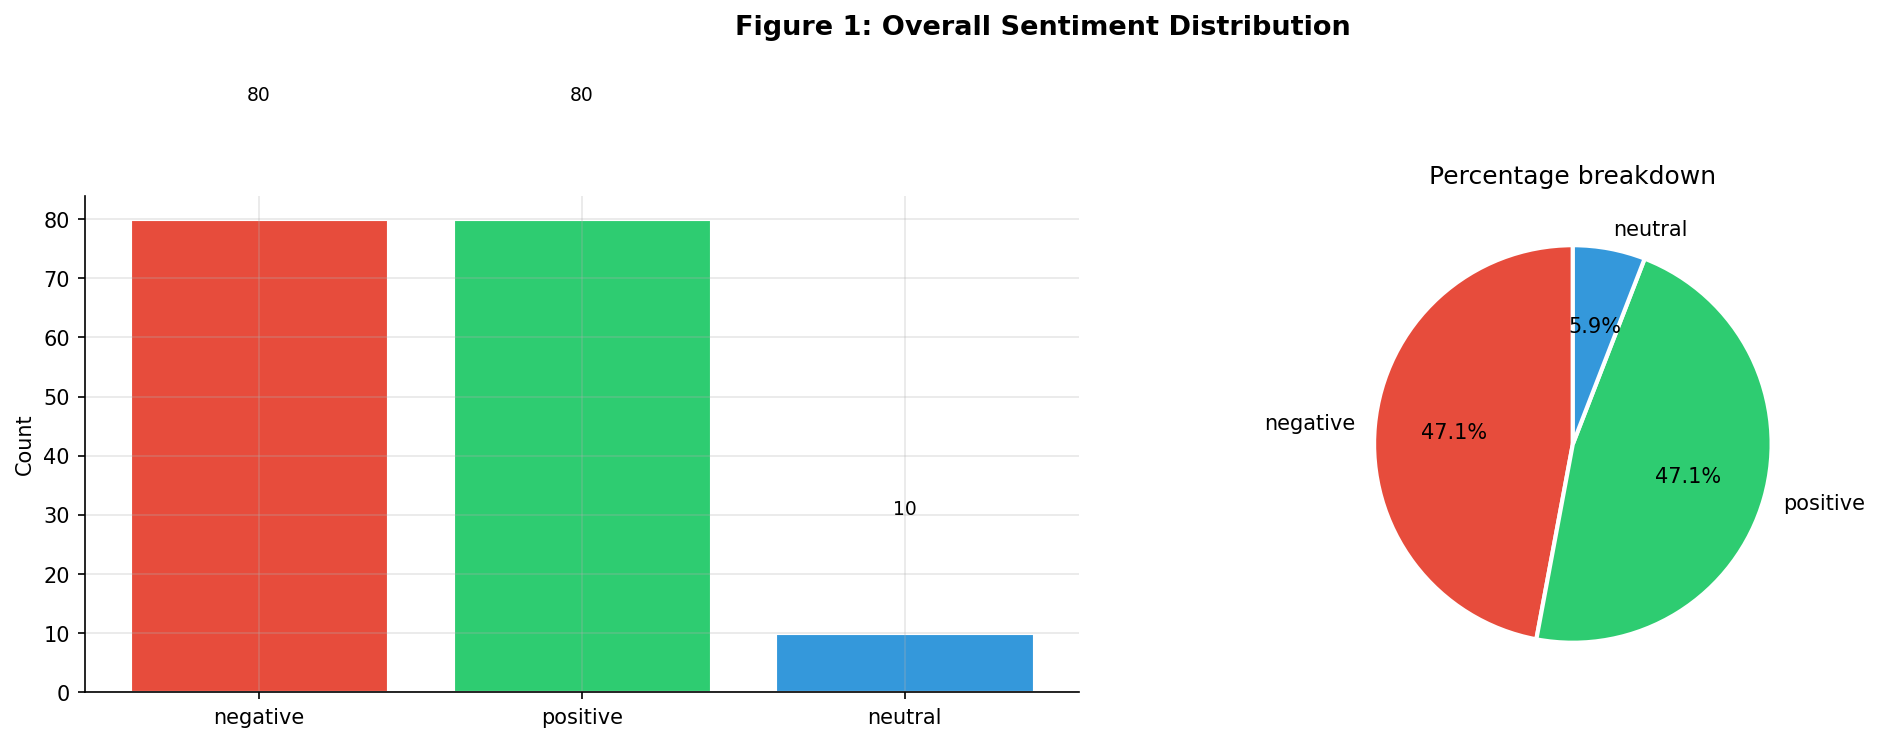

✅ Figure 1 saved.


In [5]:
# ── CELL 4: Figure 1 — Sentiment distribution ─────────────────
if sent_col:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Figure 1: Overall Sentiment Distribution',
                 fontsize=13, fontweight='bold')
    counts  = df[sent_col].value_counts()
    palette = [COLORS.get(s,'#95a5a6') for s in counts.index]
    bars = axes[0].bar(counts.index, counts.values, color=palette,
                       edgecolor='white', linewidth=1.5)
    axes[0].set_ylabel('Count')
    for b, v in zip(bars, counts.values):
        axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+20,
                     f'{v:,}', ha='center', fontsize=9)
    axes[1].pie(counts.values, labels=counts.index, colors=palette,
                autopct='%1.1f%%', startangle=90,
                wedgeprops={'edgecolor':'white','linewidth':2})
    axes[1].set_title('Percentage breakdown')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/fig1_sentiment_distribution.png',
                bbox_inches='tight', dpi=150)
    plt.show()
    print("✅ Figure 1 saved.")

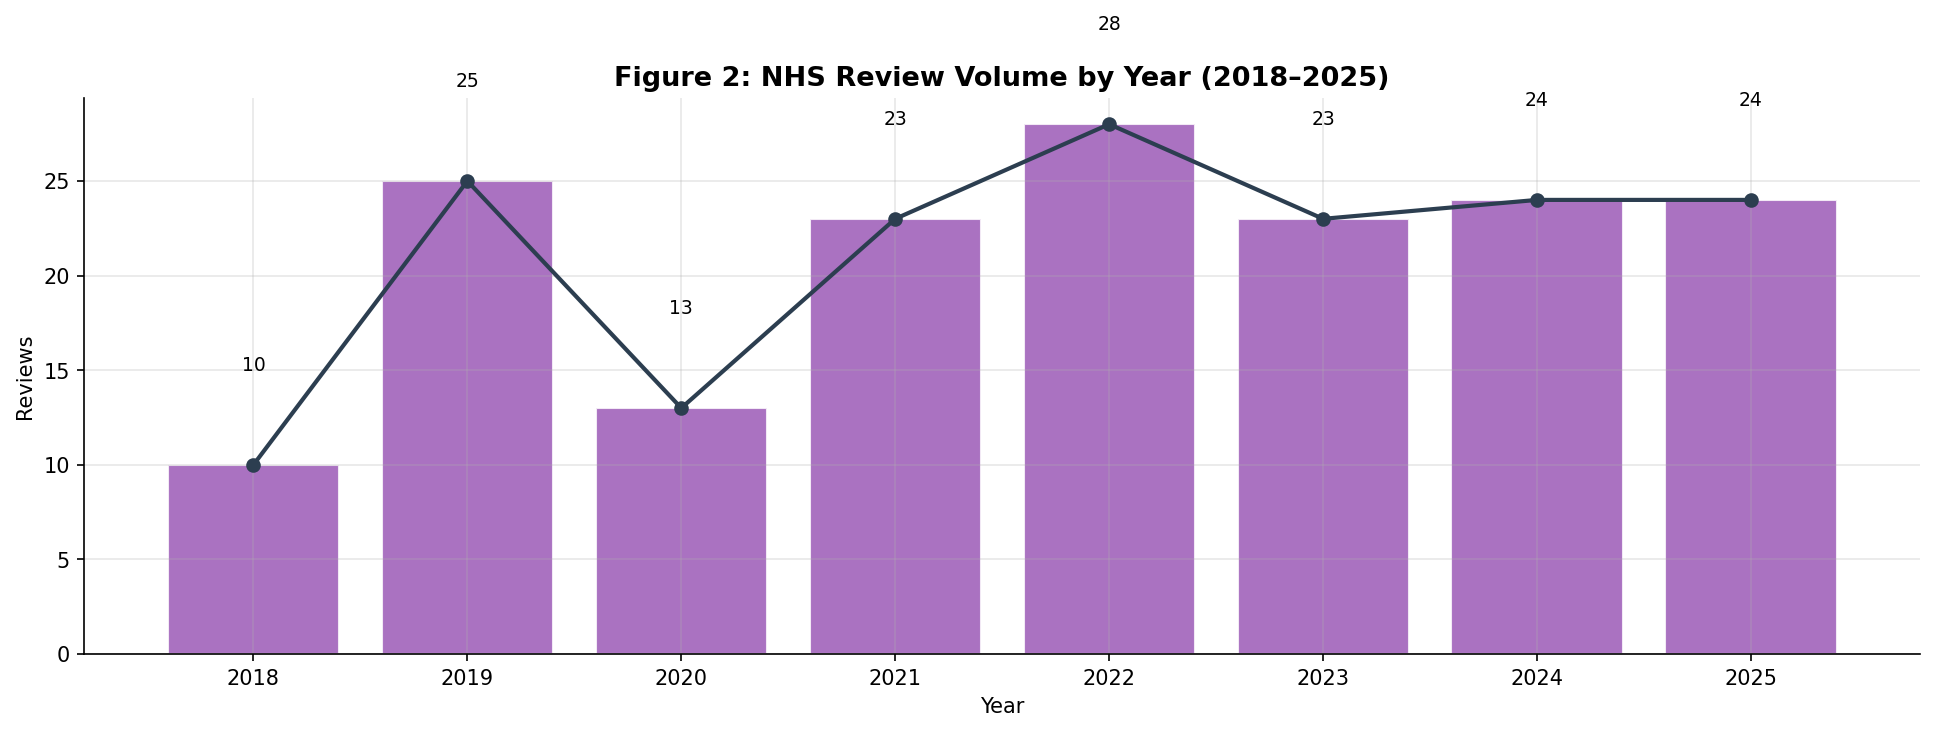

✅ Figure 2 saved.


In [6]:
# ── CELL 5: Figure 2 — Yearly volume ─────────────────────────
if 'year' in df.columns:
    fig, ax = plt.subplots(figsize=(13, 5))
    yearly = df[df['year'].between(2018,2025)].groupby('year').size()
    bars = ax.bar(yearly.index, yearly.values,
                  color=COLORS['accent'], alpha=0.85, edgecolor='white')
    ax.plot(yearly.index, yearly.values,
            color=COLORS['primary'], marker='o', lw=2, zorder=5)
    for b, v in zip(bars, yearly.values):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+5,
                f'{v:,}', ha='center', fontsize=9)
    ax.set_title('Figure 2: NHS Review Volume by Year (2018–2025)',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Year'); ax.set_ylabel('Reviews')
    ax.set_xticks(yearly.index)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/fig2_yearly_volume.png',
                bbox_inches='tight', dpi=150)
    plt.show()
    print("✅ Figure 2 saved.")

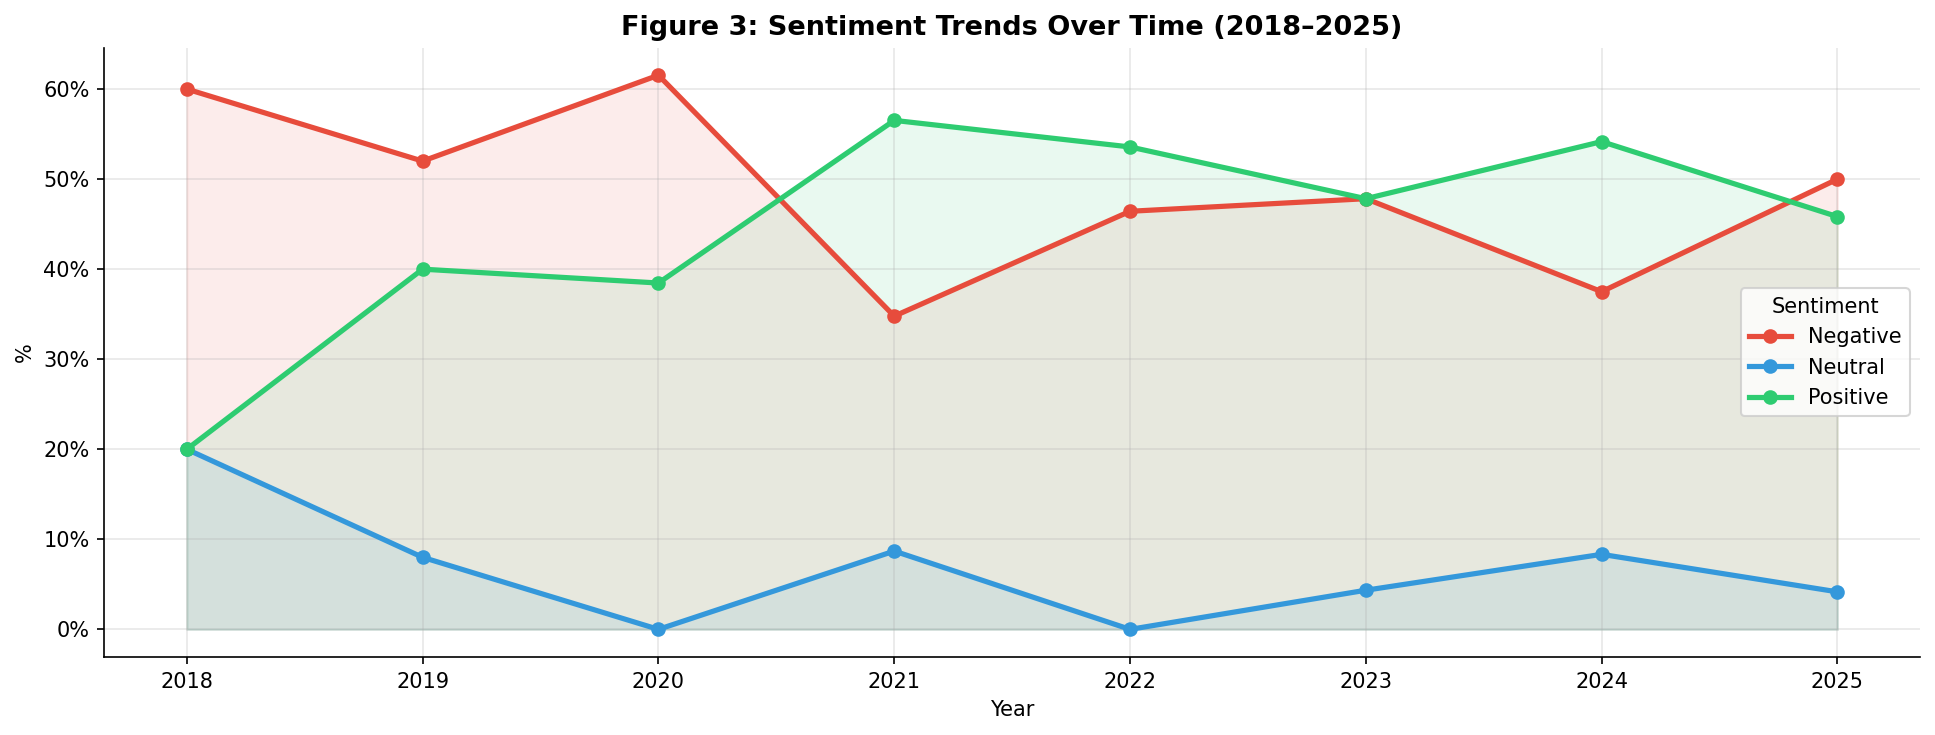

✅ Figure 3 saved.


In [7]:
# ── CELL 6: Figure 3 — Yearly sentiment trends ───────────────
if 'year' in df.columns and sent_col:
    fig, ax = plt.subplots(figsize=(13, 5))
    pivot_pct = (
        df[df['year'].between(2018,2025)]
        .groupby(['year', sent_col]).size()
        .unstack(fill_value=0)
        .pipe(lambda x: x.div(x.sum(axis=1), axis=0)*100)
    )
    for s in pivot_pct.columns:
        ax.plot(pivot_pct.index, pivot_pct[s], marker='o', lw=2.5,
                label=s.capitalize(), color=COLORS.get(s,'#95a5a6'))
        ax.fill_between(pivot_pct.index, pivot_pct[s],
                        alpha=0.1, color=COLORS.get(s,'#95a5a6'))
    ax.set_title('Figure 3: Sentiment Trends Over Time (2018–2025)',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Year'); ax.set_ylabel('%')
    ax.legend(title='Sentiment')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/fig3_sentiment_trends.png',
                bbox_inches='tight', dpi=150)
    plt.show()
    print("✅ Figure 3 saved.")

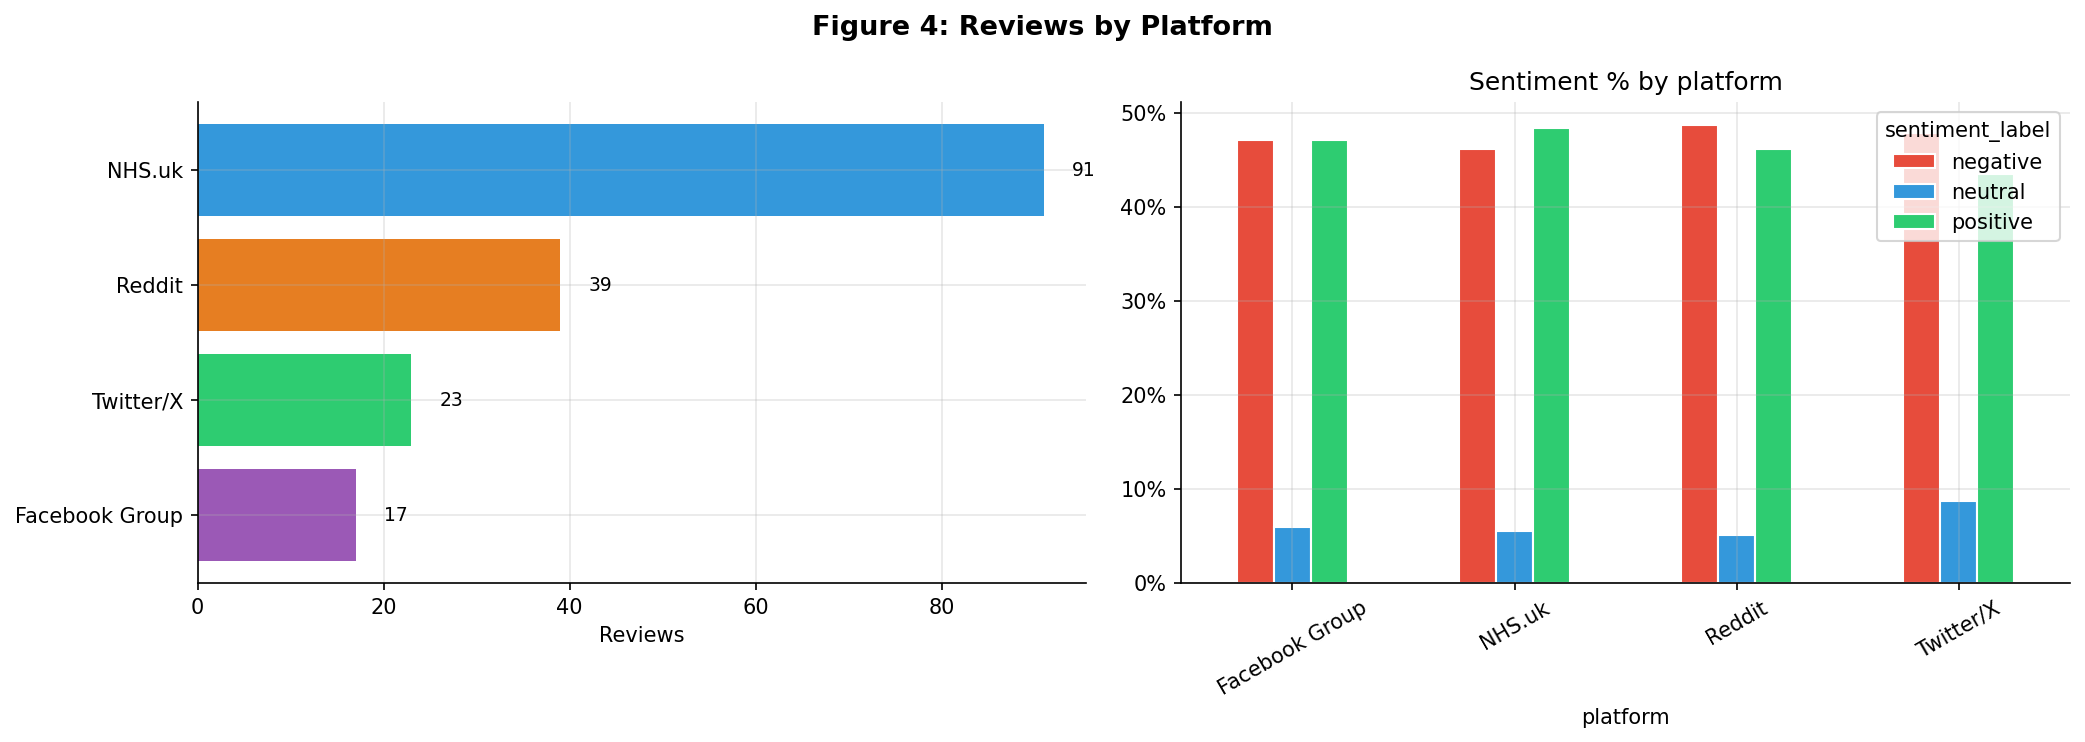

✅ Figure 4 saved.


In [8]:
# ── CELL 7: Figure 4 — Platform distribution ─────────────────
if 'platform' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14,5))
    fig.suptitle('Figure 4: Reviews by Platform',
                 fontsize=13, fontweight='bold')
    plat   = df['platform'].value_counts()
    colors = ['#3498db','#e67e22','#2ecc71','#9b59b6'][:len(plat)]
    axes[0].barh(plat.index, plat.values, color=colors)
    for i,(v,n) in enumerate(zip(plat.values, plat.index)):
        axes[0].text(v+3, i, f'{v:,}', va='center', fontsize=9)
    axes[0].set_xlabel('Reviews'); axes[0].invert_yaxis()
    if sent_col:
        cross = pd.crosstab(df['platform'], df[sent_col],
                            normalize='index')*100
        cross.plot(kind='bar', ax=axes[1],
                   color=[COLORS.get(c,'#95a5a6') for c in cross.columns],
                   edgecolor='white')
        axes[1].set_title('Sentiment % by platform')
        axes[1].tick_params(axis='x', rotation=30)
        axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/fig4_platform_distribution.png',
                bbox_inches='tight', dpi=150)
    plt.show()
    print("✅ Figure 4 saved.")

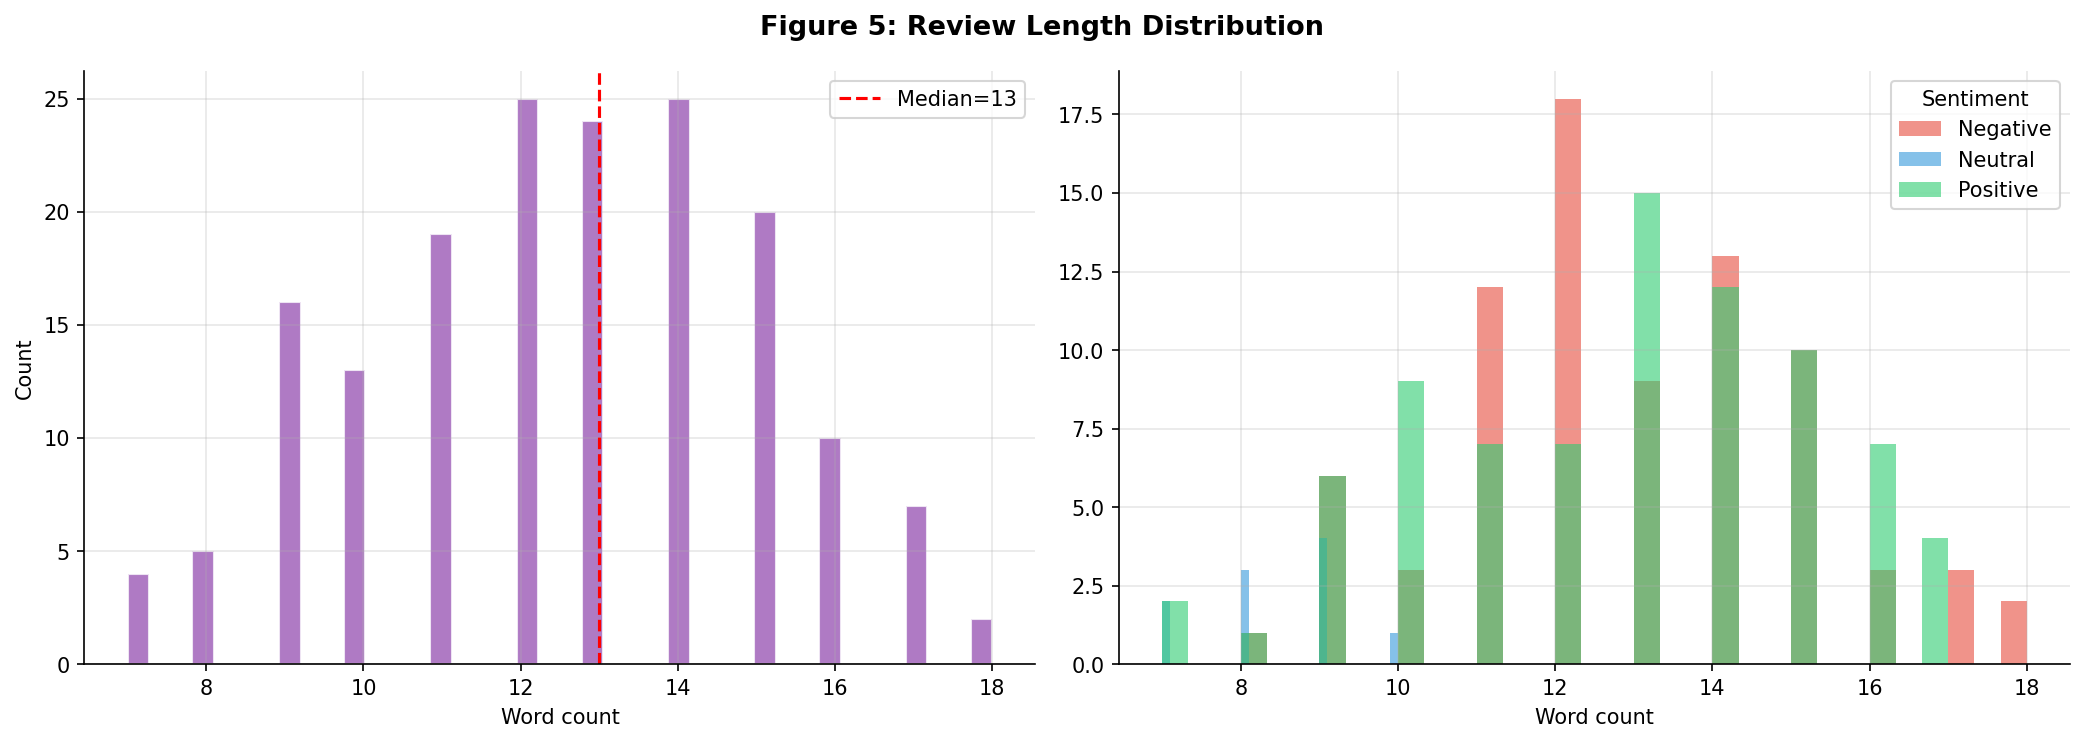

✅ Figure 5 saved.


In [9]:
# ── CELL 8: Figure 5 — Review length ─────────────────────────
if 'word_count' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14,5))
    fig.suptitle('Figure 5: Review Length Distribution',
                 fontsize=13, fontweight='bold')
    axes[0].hist(df['word_count'].clip(upper=200), bins=40,
                 color=COLORS['accent'], alpha=0.8, edgecolor='white')
    axes[0].axvline(df['word_count'].median(), color='red',
                    linestyle='--',
                    label=f"Median={df['word_count'].median():.0f}")
    axes[0].set_xlabel('Word count'); axes[0].set_ylabel('Count')
    axes[0].legend()
    if sent_col:
        for s, g in df.groupby(sent_col):
            axes[1].hist(g['word_count'].clip(upper=200), bins=30,
                         alpha=0.6, label=s.capitalize(),
                         color=COLORS.get(s,'#95a5a6'))
        axes[1].set_xlabel('Word count')
        axes[1].legend(title='Sentiment')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/fig5_review_length.png',
                bbox_inches='tight', dpi=150)
    plt.show()
    print("✅ Figure 5 saved.")

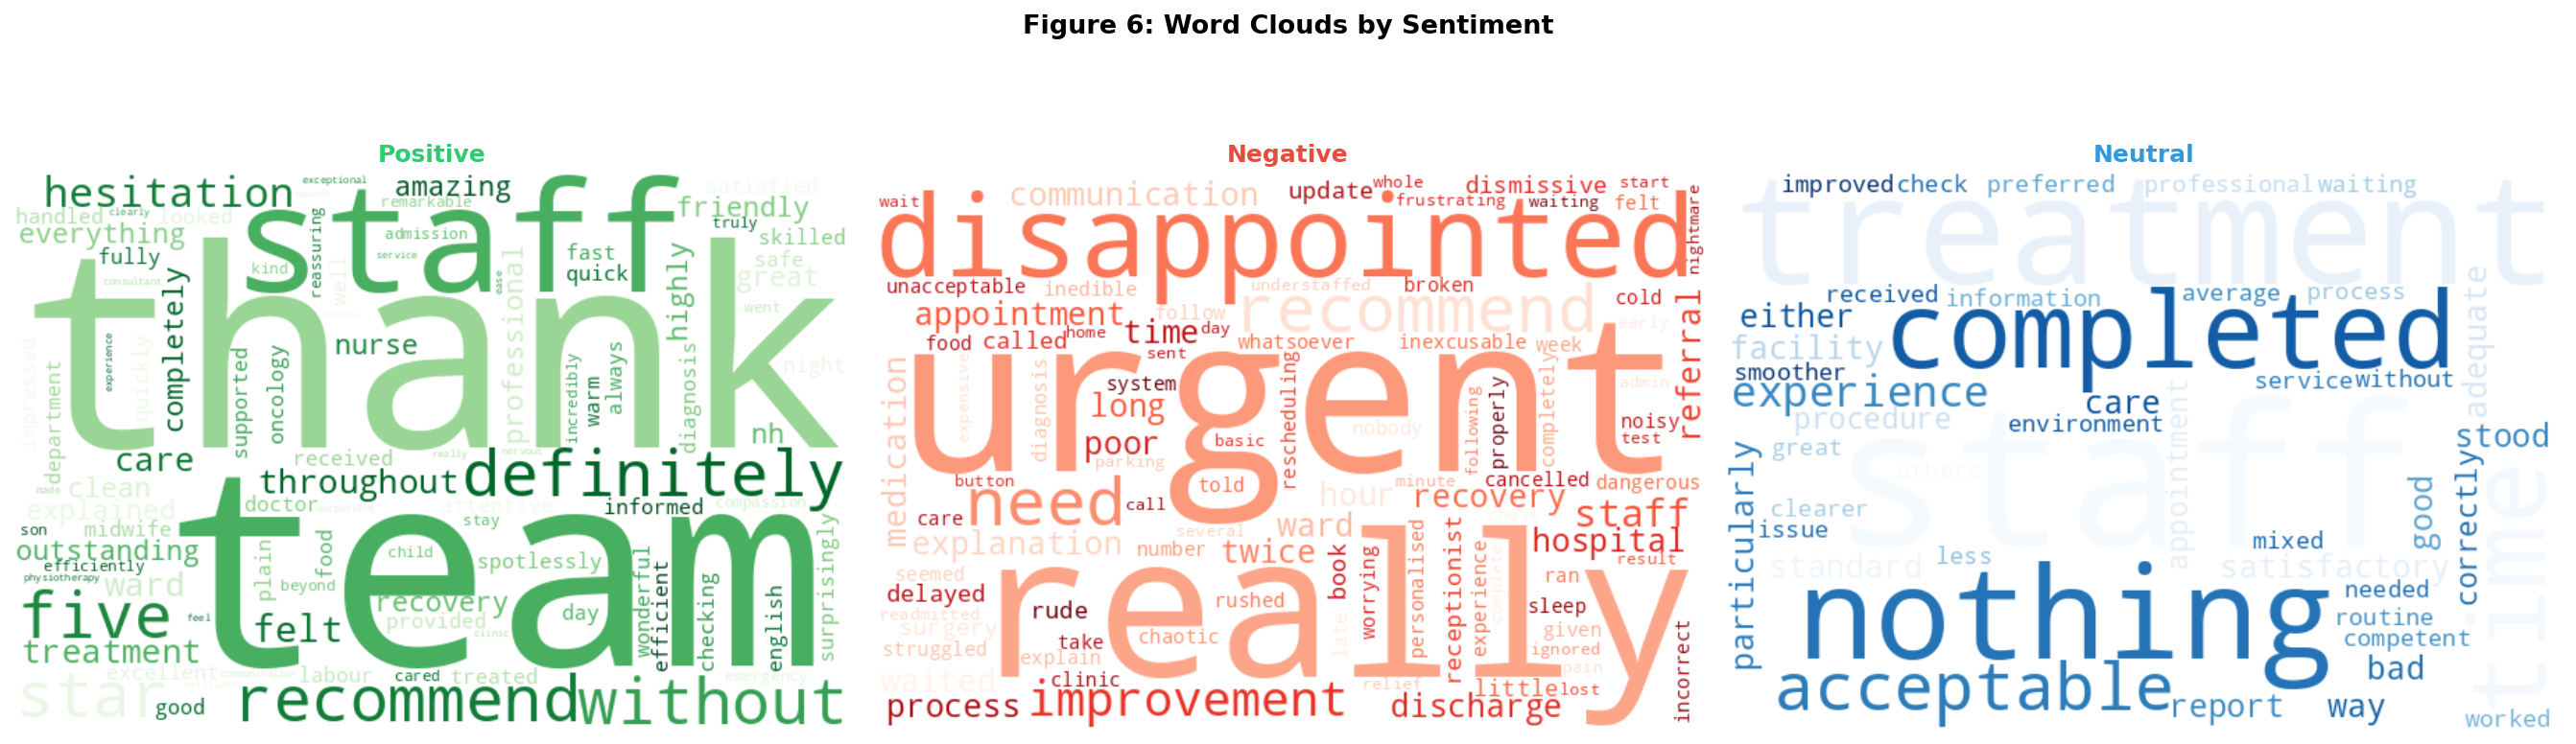

✅ Figure 6 saved.


In [10]:
# ── CELL 9: Figure 6 — Word clouds ───────────────────────────
if sent_col:
    fig, axes = plt.subplots(1, 3, figsize=(18,6))
    fig.suptitle('Figure 6: Word Clouds by Sentiment',
                 fontsize=13, fontweight='bold')
    for ax, s, cmap in zip(axes,
                            ['positive','negative','neutral'],
                            ['Greens','Reds','Blues']):
        blob = ' '.join(df[df[sent_col]==s][proc_col].dropna())
        if blob.strip():
            wc = WordCloud(width=600, height=400,
                           background_color='white', colormap=cmap,
                           max_words=100, collocations=False).generate(blob)
            ax.imshow(wc, interpolation='bilinear')
        ax.set_title(s.capitalize(), fontweight='bold',
                     color=COLORS.get(s,'#333'))
        ax.axis('off')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/fig6_wordclouds.png',
                bbox_inches='tight', dpi=150)
    plt.show()
    print("✅ Figure 6 saved.")

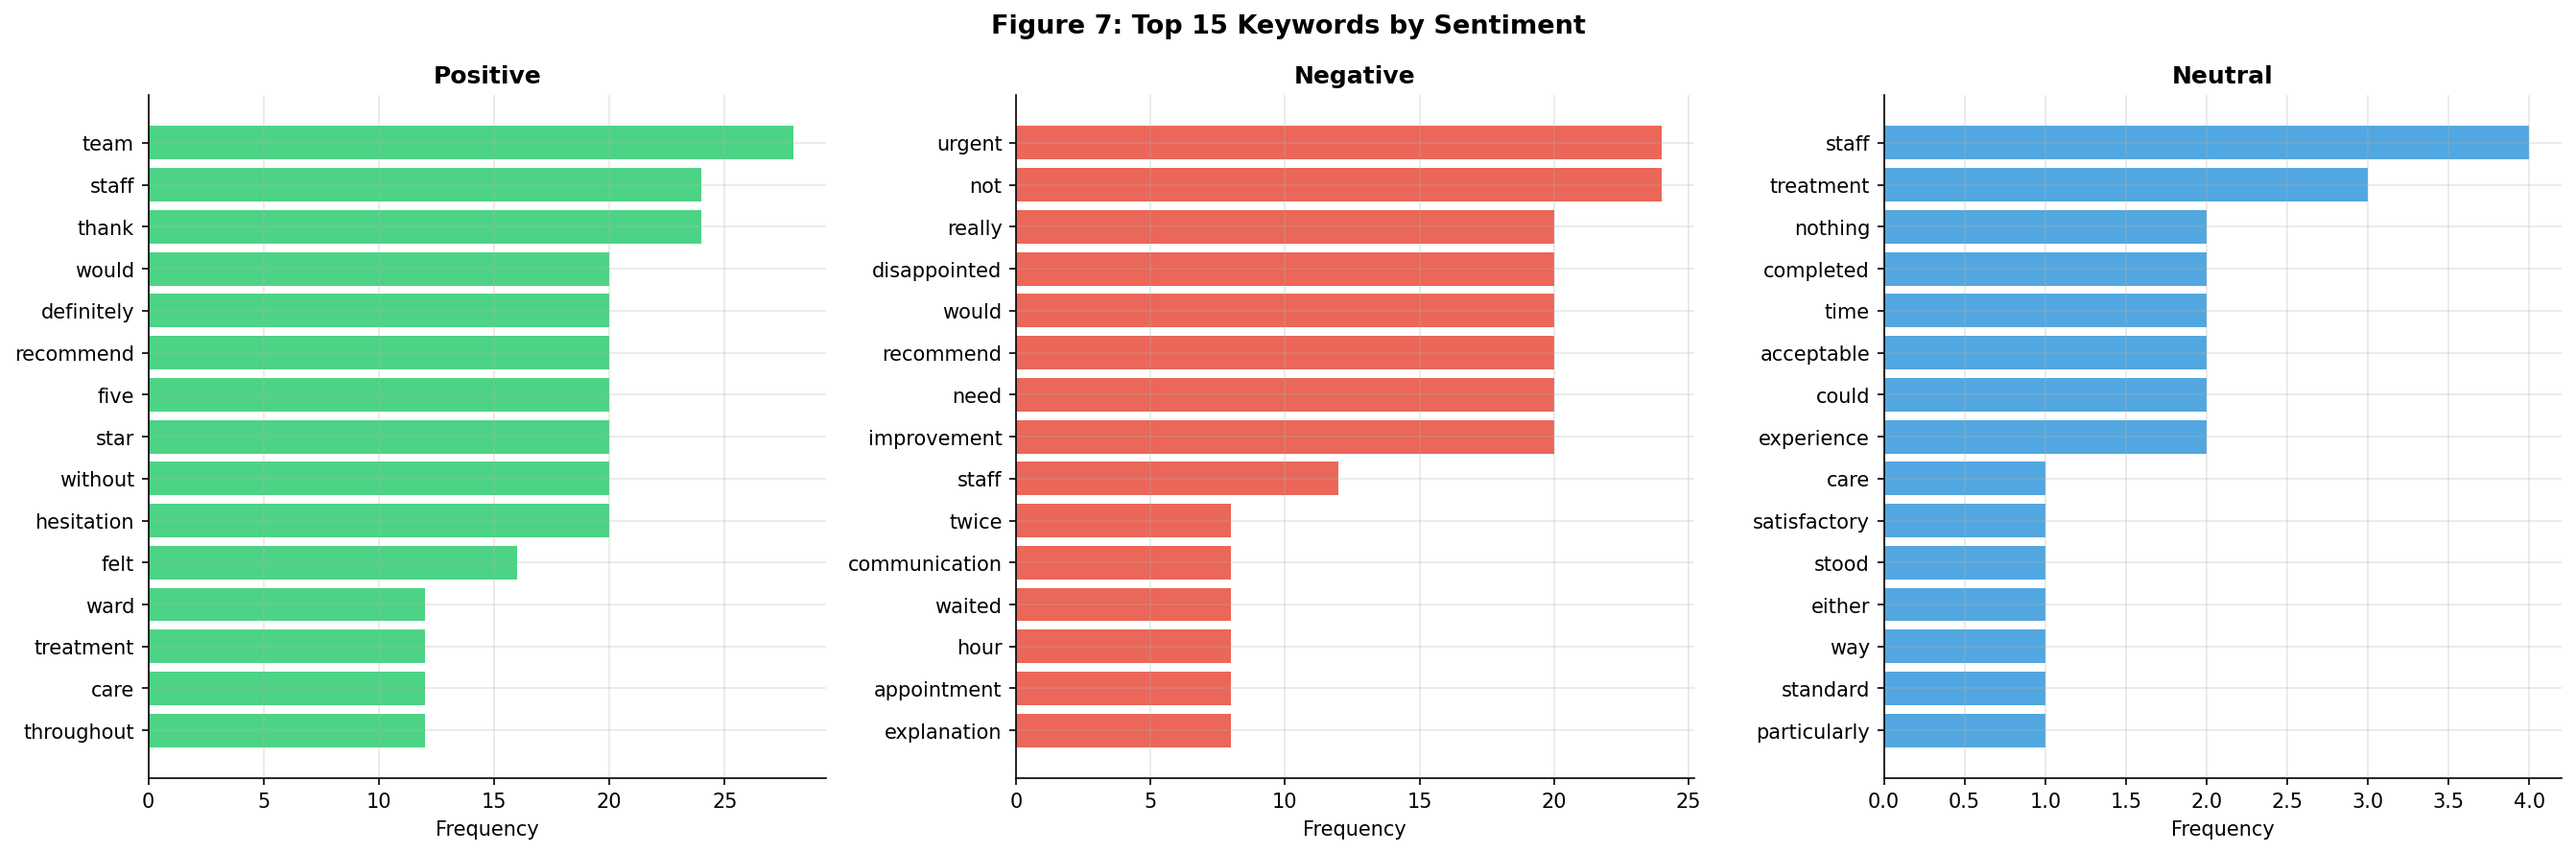

✅ Figure 7 saved.


In [11]:
# ── CELL 10: Figure 7 — Top keywords ─────────────────────────
if sent_col:
    fig, axes = plt.subplots(1, 3, figsize=(18,6))
    fig.suptitle('Figure 7: Top 15 Keywords by Sentiment',
                 fontsize=13, fontweight='bold')
    for ax, s in zip(axes, ['positive','negative','neutral']):
        words = ' '.join(df[df[sent_col]==s][proc_col].dropna()).split()
        freq  = Counter(words).most_common(15)
        if freq:
            w, c = zip(*freq)
            ax.barh(list(w)[::-1], list(c)[::-1],
                    color=COLORS.get(s,'#95a5a6'), alpha=0.85)
        ax.set_title(s.capitalize(), fontweight='bold')
        ax.set_xlabel('Frequency')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/fig7_top_keywords.png',
                bbox_inches='tight', dpi=150)
    plt.show()
    print("✅ Figure 7 saved.")

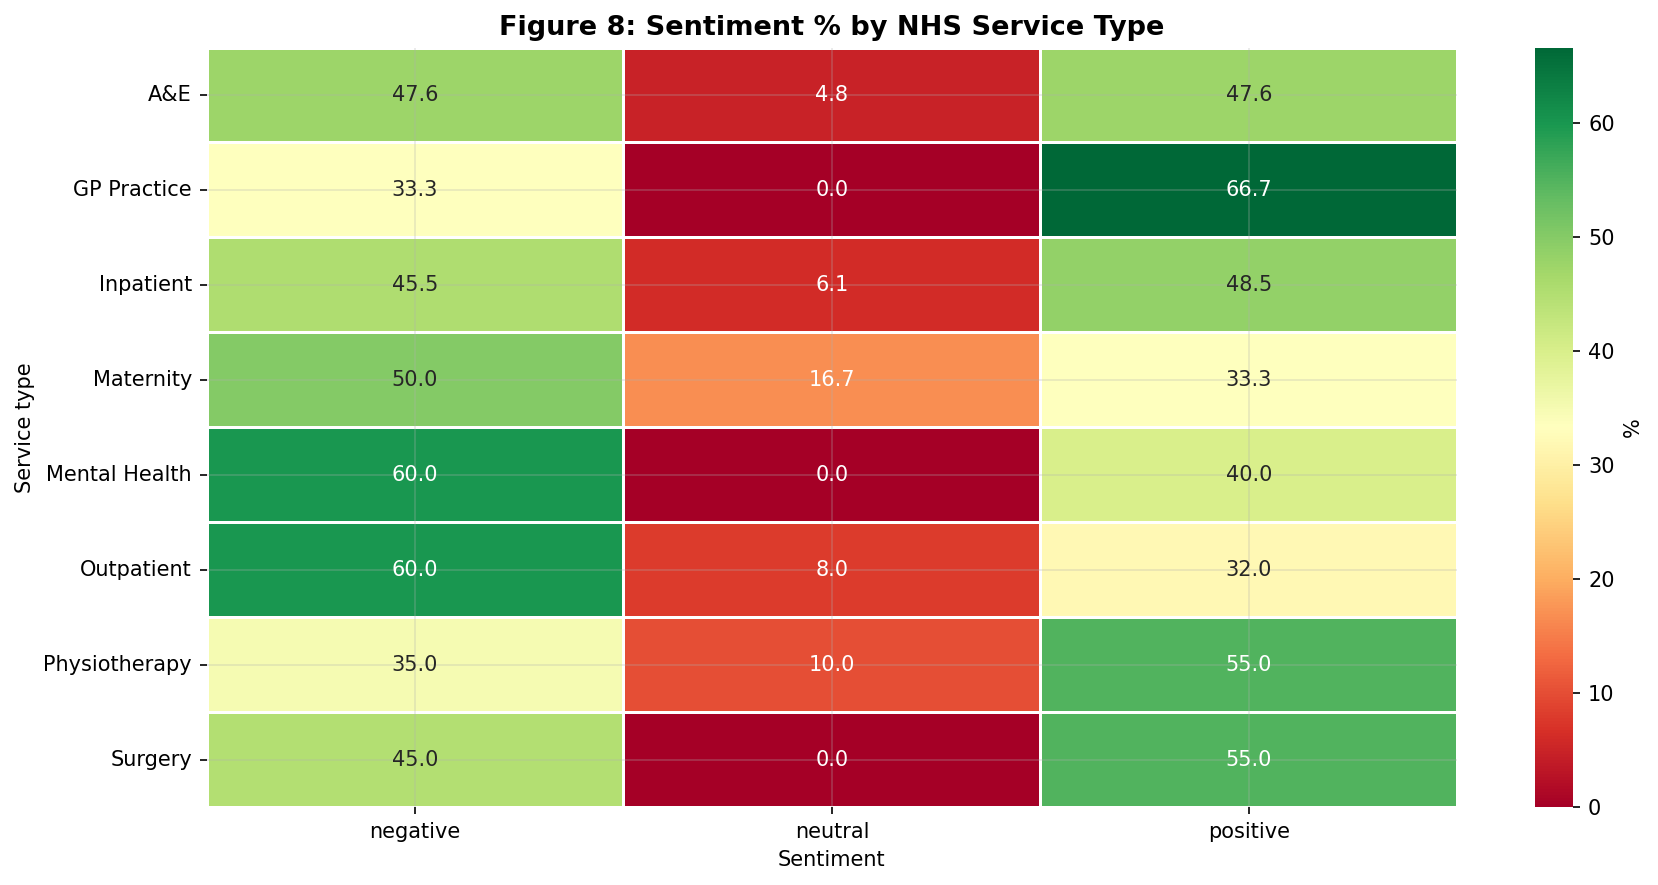

✅ Figure 8 saved.

🎯 Stage 3 EDA complete — 8 figures saved to /kaggle/working


In [12]:
# ── CELL 11: Figure 8 — Service heatmap ──────────────────────
if 'service_type' in df.columns and sent_col:
    fig, ax = plt.subplots(figsize=(12,6))
    heat = pd.crosstab(df['service_type'], df[sent_col],
                       normalize='index')*100
    sns.heatmap(heat, annot=True, fmt='.1f', cmap='RdYlGn',
                linewidths=0.5, ax=ax, cbar_kws={'label':'%'})
    ax.set_title('Figure 8: Sentiment % by NHS Service Type',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Sentiment'); ax.set_ylabel('Service type')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/fig8_service_heatmap.png',
                bbox_inches='tight', dpi=150)
    plt.show()
    print("✅ Figure 8 saved.")

# Save enriched dataframe for next stage
df.to_csv(f'{OUTPUT_DIR}/nhs_clean_data.csv', index=False)
print(f"\n🎯 Stage 3 EDA complete — 8 figures saved to {OUTPUT_DIR}")